<a href="https://colab.research.google.com/github/takuma1229/nlp100/blob/main/chapter6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第六章　機械学習

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 50

In [43]:
columns = "TITLE\tURL\tPUBLISHER\tCATEGORY\tSTORY\tHOSTNAME\tTIMESTAMP".split("\t")

In [44]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/nlp100/NewsAggregatorDataset/newsCorpora.csv", names=columns, sep="\t")
df

,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027
...,...,...,...,...,...,...,...
422933,Surgeons to remove 4-year-old's rib to rebuild...,http://www.cbs3springfield.com/story/26378648/...,WSHM-TV,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.cbs3springfield.com,1409229190251
422934,Boy to have surgery on esophagus after battery...,http://www.wlwt.com/news/boy-to-have-surgery-o...,WLWT Cincinnati,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wlwt.com,1409229190508
422935,Child who swallowed battery to have reconstruc...,http://www.newsnet5.com/news/local-news/child-...,NewsNet5.com,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.newsnet5.com,1409229190771
422936,Phoenix boy undergoes surgery to repair throat...,http://www.wfsb.com/story/26368078/phoenix-boy...,WFSB,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wfsb.com,1409229191071


情報源（publisher）が”Reuters”, “Huffington Post”, “Businessweek”, “Contactmusic.com”, “Daily Mail”の事例（記事）のみを抽出する．

In [45]:
df = df.loc[df['PUBLISHER'].isin(['Reuters', 'Huffington Post', 'Businessweek', 'Contactmusic.com', 'Daily Mail'])]

In [46]:
df

,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
13,Europe reaches crunch point on banking union,http://in.reuters.com/article/2014/03/10/eu-ba...,Reuters,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,in.reuters.com,1394470501755
14,ECB FOCUS-Stronger euro drowns out ECB's messa...,http://in.reuters.com/article/2014/03/10/ecb-p...,Reuters,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,in.reuters.com,1394470501948
20,"Euro Anxieties Wane as Bunds Top Treasuries, S...",http://www.businessweek.com/news/2014-03-10/ge...,Businessweek,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,www.businessweek.com,1394470503148
21,Noyer Says Strong Euro Creates Unwarranted Eco...,http://www.businessweek.com/news/2014-03-10/no...,Businessweek,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,www.businessweek.com,1394470503366
30,REFILE-Bad loan triggers key feature in ECB ba...,http://in.reuters.com/article/2014/03/10/euroz...,Reuters,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,in.reuters.com,1394470505070
...,...,...,...,...,...,...,...
422819,UN: Ebola Could Eventually Infect 20000 People,http://www.huffingtonpost.com/2014/08/28/ebola...,Huffington Post,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,www.huffingtonpost.com,1409228423333
422820,"Ebola toll tops 1550, continues to accelerate ...",http://in.reuters.com/article/2014/08/28/healt...,Reuters,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,in.reuters.com,1409228423827
422821,"UPDATE 1-Ebola toll tops 1550, outbreak accele...",http://in.reuters.com/article/2014/08/28/healt...,Reuters,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,in.reuters.com,1409228424525
422828,"Ebola Cases May Surpass 20000, WHO Says in Upd...",http://www.businessweek.com/news/2014-08-28/eb...,Businessweek,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,www.businessweek.com,1409228426943


抽出された事例をランダムに並び替える

In [47]:
df = df.sample(frac=1)

抽出された事例の80%を学習データ，残りの10%ずつを検証データと評価データに分割し，それぞれtrain.txt，valid.txt，test.txtというファイル名で保存する．ファイルには，１行に１事例を書き出すこととし，カテゴリ名と記事見出しのタブ区切り形式とせよ（このファイルは後に問題70で再利用する）．

In [48]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, shuffle=False)
val_df, test_df = train_test_split(test_df, test_size=0.5, shuffle=False)

In [71]:
test_df

,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP,feature
290073,"GLOBAL MARKETS-Asian shares struggle, oil firm...",http://www.reuters.com/article/2014/06/16/mark...,Reuters,b,d0peITsAkz8NVvMWill7yfDhJacEM,www.reuters.com,1402917436042,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
343637,Kindred urges Gentiva shareholders to vote for...,http://in.reuters.com/article/2014/07/01/genti...,Reuters,m,dpWkpjcz7YikitMpaLneiVI49eExM,in.reuters.com,1404262720616,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
216258,Iceland and Japan top the global life expectan...,http://www.dailymail.co.uk/health/article-2630...,Daily Mail,m,dkLflQ_x7ToPHjMhM-QWwxbwdPZnM,www.dailymail.co.uk,1400400787762,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
74570,Is 'How I Met Your Mother' The Best Ensemble C...,http://www.contactmusic.com/article/how-i-met-...,Contactmusic.com,e,dTNDcFkxpMIrspMnwiCGlmdKoRuiM,www.contactmusic.com,1396349515070,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
56800,Some of the proposals for tackling student debt,http://www.dailymail.co.uk/wires/ap/article-25...,Daily Mail,b,dDIbjJ5ZNGtVjuMoRi7xP72R72jFM,www.dailymail.co.uk,1396012906898,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...
23410,Justin Bieber - Justin Bieber Blamed Foot Inju...,http://www.contactmusic.com/story/justin-biebe...,Contactmusic.com,e,dc2H-W0h0Ovb_OMlzWA2VwdQYIK8M,www.contactmusic.com,1395239455006,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
43043,Home > Kanye West > Kanye West Found The Next ...,http://www.contactmusic.com/story/kanye-west-f...,Contactmusic.com,e,dm2XBU7l0ihhp2MpLpXwTSLvMJ7sM,www.contactmusic.com,1395777857983,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
421279,Emma Stone Attends 'Birdman' Premiere At 71st ...,http://www.contactmusic.com/article/emma-stone...,Contactmusic.com,e,deBrK5HTcD8HJYMWxhXTA_kMO0z3M,www.contactmusic.com,1409219122270,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
103165,"Ancient Daddy Longleg Ancestor Had Four Eyes, ...",http://www.huffingtonpost.com/2014/04/11/daddy...,Huffington Post,t,d-gtP0fa7i7DIUM0zfU1N9Qn4BHsM,www.huffingtonpost.com,1397296698383,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [49]:
def write_to_txt(file_name, category_list, article_list):
    file_path = "/content/drive/MyDrive/nlp100/NewsAggregatorDataset/" + file_name
    f = open(file_path, mode="w")
    for i in range(len(category_list)):
        f.write(f"{category_list[i]} \t {article_list[i]} \n")
    f.close()

In [50]:
# write_to_txt("train.txt", train_df["CATEGORY"].to_list(), train_df["TITLE"].to_list())
# write_to_txt("test.txt", test_df["CATEGORY"].to_list(), test_df["TITLE"].to_list())
# write_to_txt("val.txt", val_df["CATEGORY"].to_list(), val_df["TITLE"].to_list())


In [51]:
print(len(train_df))
print(len(test_df))
print(len(val_df))


10672
1334
1334


## 51. 特徴量抽出

学習データ，検証データ，評価データから特徴量を抽出し，それぞれtrain.feature.txt，valid.feature.txt，test.feature.txtというファイル名で保存せよ． なお，カテゴリ分類に有用そうな特徴量は各自で自由に設計せよ．記事の見出しを単語列に変換したものが最低限のベースラインとなるであろう．

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_vectorizer(title_list):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(title_list)
    return vectorizer

def extract_tfidf_feature(title_list):
    vectorizer = TfidfVectorizer()
    import gc 
    gc.collect()
    X = vectorizer.fit_transform(title_list)
    # print(vectorizer.get_feature_names())
    return X.toarray()

def extract_tfidf_feature_for_unk(title_list, corpus):
    vectorizer = TfidfVectorizer()
    _ = vectorizer.fit_transform(corpus)
    X = vectorizer.transform(title_list)
    return X.toarray()

def output_feature_to_txt(title_list):
    tfidf = extract_tfidf_feature(title_list)
    file_path = "/content/drive/MyDrive/nlp100/NewsAggregatorDataset/" 
    f = open(file_path + "train_feature.txt", mode="w")
    for scores in tfidf[:len(train_df)]:
        f.write("\t".join(map(str, scores)))
        f.write("\n")
    f.close()
    f = open(file_path + "test_feature.txt", mode="w")
    for scores in tfidf[len(train_df):len(train_df)+len(test_df)]:
        f.write("\t".join(map(str, scores)))
        f.write("\n")
    f.close()
    f = open(file_path + "val_feature.txt", mode="w")
    for scores in tfidf[len(train_df)+len(test_df):]:
        f.write("\t".join(map(str, scores)))
        f.write("\n")
    f.close()



In [53]:
extract_tfidf_feature(df["TITLE"].to_list())



array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [54]:
# output_feature_to_txt(df["TITLE"].to_list())

In [55]:
#tfidfは未知語に対する問題がある...

## 52. 学習
51で構築した学習データを用いて，ロジスティック回帰モデルを学習せよ．

In [99]:
vectorizer = extract_vectorizer(df["TITLE"].to_list())
feature_list = extract_tfidf_feature(df["TITLE"])
X_train = feature_list[:len(train_df)]
X_train = pd.DataFrame(X_train, columns=vectorizer.get_feature_names())
X_val = feature_list[len(train_df):len(train_df)+len(val_df)]
X_val = pd.DataFrame(X_val, columns=vectorizer.get_feature_names())
X_test = feature_list[len(train_df)+len(val_df):]
X_test = pd.DataFrame(X_test, columns=vectorizer.get_feature_names())

print(len(X_test))

1334


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [100]:
# train_df

In [ ]:
from sklearn.linear_model import LogisticRegression

#b = business, t = science and technology, e = entertainment, m = health
y_train = train_df["CATEGORY"]

# print(X_train)
# print("===")
# print(y_train)

lr = LogisticRegression(max_iter=10000, random_state=123)
lr.fit(X_train, y_train)

## 53. 予測
52で学習したロジスティック回帰モデルを用い，与えられた記事見出しからカテゴリとその予測確率を計算するプログラムを実装せよ．

In [ ]:
text = "i think therefore i am! hdufhauiai"
feature = extract_tfidf_feature_for_unk([text], df["TITLE"].to_list())
lr.predict(feature)

## 54. 正解率の計測
52で学習したロジスティック回帰モデルの正解率を，学習データおよび評価データ上で計測せよ．

In [ ]:
#まずはTrainデータについて正解率を計測
from sklearn.metrics import classification_report
pred_train = lr.predict(X_train)
print(classification_report(y_train, pred_train))

In [ ]:
#テストデータについても正解率を計測
#b = business, t = science and technology, e = entertainment, m = health
y_test = test_df["CATEGORY"].to_list()

print(X_test)
print(y_test)

pred_test = lr.predict(X_test)
print(len(y_test))
print(len(pred_test))
# print(classification_report(y_test, pred_test))

#過学習っぽい

## 55. 混同行列の作成
52で学習したロジスティック回帰モデルの混同行列（confusion matrix）を，学習データおよび評価データ上で作成せよ

他クラス分類におけるconfusion matrixの説明図
（https://atmarkit.itmedia.co.jp/ait/articles/2208/17/news039.html より引用）

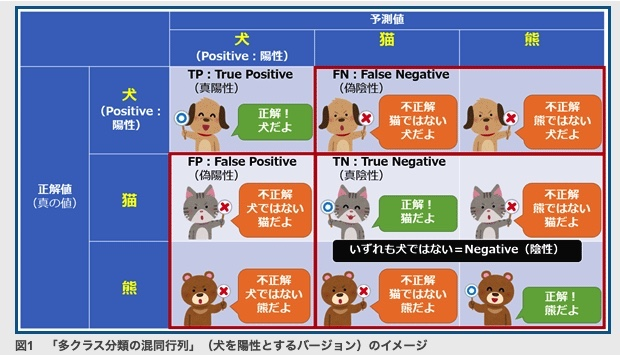

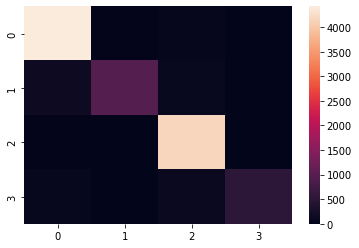

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

#まず学習データ
cm_train = confusion_matrix(y_train, pred_train)
sns.heatmap(cm_train)

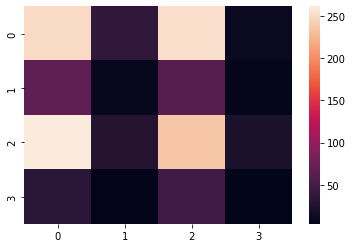

In [63]:
#次にテストデータ
cm_test = confusion_matrix(y_test, pred_test)
sns.heatmap(cm_test)

## 56. 適合率，再現率，F1スコアの計測
52で学習したロジスティック回帰モデルの適合率，再現率，F1スコアを，評価データ上で計測せよ．カテゴリごとに適合率，再現率，F1スコアを求め，カテゴリごとの性能をマイクロ平均（micro-average）とマクロ平均（macro-average）で統合せよ

micro-average, macro-average, weighted-averageについては以下の記事を要参照
https://www.haya-programming.com/entry/2018/03/14/112454#%E3%83%9E%E3%82%AF%E3%83%AD%E5%B9%B3%E5%9D%87

1. マクロ平均
  - クラスごとのデータ件数の比率を考慮しない
  - クラスごとの件数がbalancedならばこれを使っても問題ないパターンが多い
  - 「件数に関わらず、どのクラスにも同じ価値がある」とみなす
2. マイクロ平均
  - クラスごとのデータ件数の比率を考慮する
  - 件数が多いクラスの評価ほど全体の評価に強く影響する

In [64]:
#macro-averageについてはclassification_reportで既に算出している。
#micro-averageを新たに算出
from sklearn.metrics import precision_score, recall_score, f1_score

#まずはtrainから
print(("micro precision : {}").format(precision_score(y_train, pred_train, average="micro")))
print(("micro recall : {}").format(recall_score(y_train, pred_train, average="micro")))
print(("micro f1_score : {}").format(f1_score(y_train, pred_train, average="micro")))


micro precision : 0.945839580209895
micro recall : 0.945839580209895
micro f1_score : 0.9458395802098951


In [65]:
#次にtest
print(("micro precision : {}").format(precision_score(y_test, pred_test, average="micro")))
print(("micro recall : {}").format(recall_score(y_test, pred_test, average="micro")))
print(("micro f1_score : {}").format(f1_score(y_test, pred_test, average="micro")))

micro precision : 0.37256371814092953
micro recall : 0.37256371814092953
micro f1_score : 0.3725637181409295


In [66]:
#micro-averageは同一スコアになってよいっぽいが、なぜそうなるのかがよくわかっていない......

## 57. 特徴量の重みの確認
52で学習したロジスティック回帰モデルの中で，重みの高い特徴量トップ10と，重みの低い特徴量トップ10を確認せよ．

-  np.argsort[n] は「n番目（実際はindexは0始まりなのでn+1だが）に小さい値のindex」を示していることが理解のポイント。

In [67]:
#重みはcoef_を見ることでわかる
#shapeは(n_classes, n_features)

import numpy as np

weights = lr.coef_
weight_score_list = []

for feature in range(len(lr.coef_[0])):
    weight_sum = 0
    for cls in range(4):
        weight_sum += abs(weights[cls][feature])
    weight_score_list.append(weight_sum/4)

argsorted = np.argsort(weight_score_list)

smallest_10_feature_indices = []
largest_10_feature_indices = []

for i in range(10):
    smallest_10_feature_indices.append(argsorted[i])
    largest_10_feature_indices.append(argsorted[-1*i])

def extract_tfidf_words(title_list):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(title_list)
    words = vectorizer.get_feature_names()
    return words

words = extract_tfidf_words(df["TITLE"].to_list())

#上位10特徴量
for i, index in enumerate(largest_10_feature_indices):
    print("重みトップ{}位: {}".format(i+1, words[index]))

print("\n")
#下位10特徴量
for i, index in enumerate(smallest_10_feature_indices):
    print("重みワースト{}位: {}".format(i+1, words[index]))


重みトップ1位: œwaist
重みトップ2位: google
重みトップ3位: facebook
重みトップ4位: apple
重みトップ5位: ebola
重みトップ6位: study
重みトップ7位: update
重みトップ8位: cancer
重みトップ9位: microsoft
重みトップ10位: climate


重みワースト1位: œwaist
重みワースト2位: shrine
重みワースト3位: crawford
重みワースト4位: shutting
重みワースト5位: covering
重みワースト6位: sidesteps
重みワースト7位: couture
重みワースト8位: sifts
重みワースト9位: sighting
重みワースト10位: sightseeing


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


## 58. 正則化パラメータの変更
ロジスティック回帰モデルを学習するとき，正則化パラメータを調整することで，学習時の過学習（overfitting）の度合いを制御できる．異なる正則化パラメータでロジスティック回帰モデルを学習し，学習データ，検証データ，および評価データ上の正解率を求めよ．実験の結果は，正則化パラメータを横軸，正解率を縦軸としたグラフにまとめよ

sklearnのlogistic regressionで正則化パラメータは以下の`penalty`

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

```
Warning Some penalties may not work with some solvers. See the parameter 
solver below, to know the compatibility between the penalty and solver.
```
solverによっては対応してない正則化パラメータがあるので、solverプロパティの調整が必要になることがある

In [68]:
from sklearn.metrics import accuracy_score

penalty_list = ["none", "l2", "l1", "elasticnet"]
norm_list = []
train_acc = []
val_acc = []
test_acc = []


def train(norm_strength):
    X_train = train_df["feature"].to_list()
    train_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3})
    y_train = train_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3}).to_list()

    lr = LogisticRegression(max_iter=10000, C=norm_strength, random_state=123)
    lr.fit(X_train, y_train)
    return lr

def train_score(model):
    pred_train = model.predict(X_train)
    train_acc.append(accuracy_score(y_train, pred_train))
    print(classification_report(y_train, pred_train))

def val_score(model):
    X_val = val_df["feature"].to_list()
    val_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3})
    y_val = val_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3}).to_list()

    pred_val = lr.predict(X_val)
    val_acc.append(accuracy_score(y_val, pred_val))
    print(classification_report(y_val, pred_val))

def test_score(model):
    X_test = test_df["feature"].to_list()
    test_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3})
    y_test = test_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3}).to_list()

    pred_test = lr.predict(X_test)
    test_acc.append(accuracy_score(y_test, pred_test))
    print(classification_report(y_test, pred_test))

In [69]:
import math
import tqdm

for norm_strength in range(1,100):
    norm_strength =math.log(1 + norm_strength / 10)
    norm_list.append(norm_strength)
    print(f"penalty: {norm_strength}")
    lr = train(norm_strength)
    print("=====train=====")
    train_score(lr)
    print("=====val=====")
    val_score(lr)
    print("=====test=====")
    test_score(lr)

    print("\n\n")



penalty: 0.09531017980432493
=====train=====
              precision    recall  f1-score   support

           0       0.80      0.94      0.87      4502
           1       0.98      0.05      0.10      1232
           2       0.77      0.98      0.86      4202
           3       1.00      0.00      0.01       736

    accuracy                           0.79     10672
   macro avg       0.89      0.49      0.46     10672
weighted avg       0.83      0.79      0.72     10672

=====val=====
              precision    recall  f1-score   support

           0       0.44      0.46      0.45       575
           1       0.00      0.00      0.00       146
           2       0.39      0.53      0.45       529
           3       0.00      0.00      0.00        84

    accuracy                           0.41      1334
   macro avg       0.21      0.25      0.23      1334
weighted avg       0.34      0.41      0.37      1334

=====test=====


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.41      0.50      0.45       550
           1       0.33      0.01      0.03       146
           2       0.40      0.48      0.44       548
           3       0.00      0.00      0.00        90

    accuracy                           0.41      1334
   macro avg       0.29      0.25      0.23      1334
weighted avg       0.37      0.41      0.37      1334




penalty: 0.1823215567939546
=====train=====
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4502
           1       0.97      0.26      0.41      1232
           2       0.81      0.98      0.89      4202
           3       1.00      0.15      0.26       736

    accuracy                           0.83     10672
   macro avg       0.90      0.59      0.61     10672
weighted avg       0.85      0.83      0.79     10672

=====val=====
              precision    recall  f1-score   support

           0  

KeyboardInterrupt: ignored